# Augmentations-2: Augmentations

In [1]:
import os
import time
from pathlib import Path

root = Path.cwd()
print(root)
if root.name == "ipynb":
    root = root.parent
    os.chdir(root)
print(root)

import zarr
import tifffile
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.ndimage import rotate

# Tif
FISBE_DIR = root / "fisbe"
# Zarr
ORIGINAL_DIR = root / "fisbe/completely/test"
# PNG
ORIGINAL_MIP_DIR = root / "fisbe/mips/completely/test"


/scratch/wmz2007/neuroinfo_fruitfly/ipynb
/scratch/wmz2007/neuroinfo_fruitfly


## Helper Functions

### Imaging

In [2]:
PCT_LOW, PCT_HIGH, GAMMA = 1.0, 99.5, 0.72
def enhance_display(data: np.ndarray) -> np.ndarray:
    """Shared contrast + gamma; same defaults as web/server/services/volume_pipeline.py."""
    v = data.astype(np.float32)
    if not np.any(v > 0):
        return np.zeros_like(v)
    sample = v[v > 0] if np.count_nonzero(v) > 256 else v.ravel()
    lo, hi = np.percentile(sample, [PCT_LOW, PCT_HIGH])
    if hi <= lo:
        lo, hi = float(v.min()), float(v.max())
    if hi <= lo:
        return np.zeros_like(v)
    return np.clip((v - lo) / (hi - lo), 0, 1) ** GAMMA

def fisbe_rgb_mip(raw_czyx, z_axis=1) -> np.ndarray:
    """raw: CZYX. Returns Y×X×3 uint8, web-matched vibrance."""
    c = min(raw_czyx.shape[0], 3)
    mip_cyx = np.asarray(raw_czyx[:c], dtype=np.float32).max(axis=z_axis)  # C,Y,X
    rgb01 = enhance_display(mip_cyx)  # shared stretch across channels (keeps hue)
    return np.moveaxis((rgb01 * 255).astype(np.uint8), 0, -1)

In [24]:
def fisbe_gt_instance_mip(labels, z_axis=1):
    arr = np.asarray(labels)        # (Z, Y, X)
    mip = arr.max(axis=z_axis)      # (Y, X)

    rgb = np.zeros((*mip.shape, 3), dtype=np.float32)
    for lab in np.unique(mip):
        if lab == 0:
            continue
        color = np.random.randint(72, 255, 3).astype(np.float32)
        rgb[mip == lab] = color
    rgb /= 255.0

    return rgb

    # fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=100)
    # ax.imshow(rgb)
    # ax.set_title(f"GT instance MIP {sample_name}")
    # ax.axis("off")
    # plt.show()


In [25]:
def mip_biapy_gt_instance(labels, sample_name, z_axis=0):
    arr = np.asarray(labels)
    mip = arr.max(axis=z_axis)       # (Y, X)

    rgb = np.zeros((*mip.shape, 3), dtype=np.float32)
    for lab in np.unique(mip):
        if lab == 0:
            continue
        color = np.random.randint(72, 255, 3).astype(np.float32)
        rgb[mip == lab] = color
    rgb /= 255.0

    fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=100)
    ax.imshow(rgb)
    ax.set_title(f"GT instance MIP {sample_name}")
    ax.axis("off")
    plt.show()


### Stats

In [26]:
def per_channel_stats(data: np.ndarray, axis: int = 0) -> pd.DataFrame:
    """Basic stats of values across channels (axis 0 for CZYX).

    Expects shape like (C, Z, Y, X), e.g. (3, 390, 680, 680) uint16.
    """
    data = np.asarray(data)
    n_ch = data.shape[axis]
    rows = []
    for c in range(n_ch):
        ch = np.take(data, c, axis=axis).ravel()
        nonzero = ch[ch > 0]
        rows.append({
            "channel": c,
            "dtype": str(data.dtype),
            "n": ch.size,
            "n_nonzero": int(nonzero.size),
            "min": int(ch.min()) if ch.size else np.nan,
            "max": int(ch.max()) if ch.size else np.nan,
            "mean": float(ch.mean()) if ch.size else np.nan,
            "std": float(ch.std()) if ch.size else np.nan,
            "median": float(np.median(ch)) if ch.size else np.nan,
            "p1": float(np.percentile(ch, 1)) if ch.size else np.nan,
            "p99": float(np.percentile(ch, 99)) if ch.size else np.nan,
            "mean_nonzero": float(nonzero.mean()) if nonzero.size else 0.0,
            "median_nonzero": float(np.median(nonzero)) if nonzero.size else 0.0,
        })
    return pd.DataFrame(rows).set_index("channel")


def per_channel_histogram(
    data: np.ndarray,
    sample_name: str,
    axis: int = 0,
    bins: int = 256,
    range_=None,
    skip_zeros: bool = True,
    log_y: bool = True,
    figsize=(12, 3.5),
):
    """Basic histogram of value distribution across channels (axis 0 for CZYX).

    Plots one subplot per channel. Returns (fig, axes, counts).
    """
    data = np.asarray(data)
    n_ch = data.shape[axis]
    if range_ is None:
        range_ = (int(data.min()), int(data.max()) + 1)

    fig, axes = plt.subplots(1, n_ch, figsize=figsize, sharey=True)
    if n_ch == 1:
        axes = [axes]

    counts = []
    for c, ax in enumerate(axes):
        ch = np.take(data, c, axis=axis).ravel()
        if skip_zeros:
            ch = ch[ch > 0]
        hist, edges = np.histogram(ch, bins=bins, range=range_)
        counts.append(hist)
        centers = (edges[:-1] + edges[1:]) / 2
        ax.bar(centers, hist, width=np.diff(edges), align="center", alpha=0.8)
        ax.set_title(f"channel {c}")
        ax.set_xlabel("value")
        if log_y:
            ax.set_yscale("log")
        ax.set_xlim(range_)

    axes[0].set_ylabel("count" + (" (log)" if log_y else ""))
    fig.suptitle(f"Per-channel value histogram {sample_name}", y=1.02)
    fig.tight_layout()
    return fig, axes, counts


## Stats

In [27]:
# total_stats = []
# for p in ORIGINAL_DIR.glob('*.zarr'):
#     sample = p.stem
#     raw = zarr.open(p, mode="r", path="volumes/raw")
#     total_stats.append(per_channel_stats(raw))
# total_stats= pd.concat(total_stats)
# total_stats

In [28]:
# for p in ORIGINAL_DIR.glob('*.zarr'):
#     sample = p.stem
#     raw = zarr.open(p, mode="r", path="volumes/raw")
#     per_channel_histogram(data=raw, sample_name=sample)

## Viewing Augmentation 

In [67]:
from collections.abc import Callable
from concurrent.futures import ThreadPoolExecutor, as_completed


def plot_augmentation_samples(
        sample:str, split:str, 
        augmentation_name:str, 
        raw:bool, plotting_func:Callable,
        seed=42,
        sample_selection=4,
        subplots=[2, 2],
        fig_size=(8,8)
):
    SAMPLE = sample + "*"
    SPLIT = split
    AUG_NAME = augmentation_name
    if raw:
        AUG_DATA_DIR = FISBE_DIR / AUG_NAME / SPLIT / 'raw'
    else:
        AUG_DATA_DIR = FISBE_DIR / AUG_NAME / SPLIT / 'label'
    print(AUG_DATA_DIR)
    print(SAMPLE)

    sample_augmentations = sorted(AUG_DATA_DIR.glob(f"{SAMPLE}.tif"))
    total_augmentaions = len(sample_augmentations)
    print(f"Total augmentations for sample found: {total_augmentaions}")
    rng = np.random.default_rng(seed)
    print(f"Selecting ({sample_selection}) samples")
    sample_selection = rng.integers(0, total_augmentaions, sample_selection)
    sample_augmentations = [sample_augmentations[i] for i in sample_selection]

    # Define thread job
    def load_mip(path: Path):
        img = tifffile.imread(path)
        print(f"Image Shape: {img.shape}")
        img = np.moveaxis(img, 0, 1)  # BiaPy ZCYX -> CZYX
        return path, plotting_func(img, 1)

    # Loading Samples
    mips = [None] * len(sample_augmentations)
    with ThreadPoolExecutor(max_workers=2) as ex:
        mips = list(
            tqdm(
                ex.map(load_mip, sample_augmentations), 
                total=len(sample_augmentations)
            )
        )

    print(f"Transformed image shape: {mips[0][1].shape}")

    # Plotting Samples
    for chunk_start in range(0, len(mips), 4):
        chunk = mips[chunk_start : chunk_start + 4]
        fig, axes = plt.subplots(nrows=subplots[0], ncols=subplots[0], figsize=fig_size, dpi=150, squeeze=False)
        for i, (path, mip) in enumerate(chunk):
            ax = axes[i // 2, i % 2]
            ax.imshow(mip)
            ax.set_title(path.stem.replace("R38F04-20181005_63_G3", ""), fontsize=8)
            ax.axis("off")
        plt.tight_layout(pad=0.2, w_pad=0.1, h_pad=0.2)
        plt.show()



In [68]:
SAMPLE = "JRC_SS04989-20160318_24_A2"
SPLIT = "test"
AUG_NAME = "biapy-channel-rot"
RNG_SEED = 22

### No Augmentations

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-no-aug/test/raw
JRC_SS04989-20160318_24_A2*
Total augmentations for sample found: 1
Selecting (1) samples


  0%|          | 0/1 [00:00<?, ?it/s]

Image Shape: (390, 3, 680, 680)


100%|██████████| 1/1 [00:04<00:00,  4.12s/it]

Transformed image shape: (680, 680, 3)


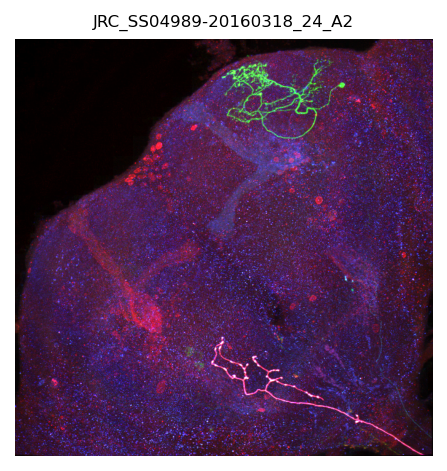

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-no-aug/test/label
JRC_SS04989-20160318_24_A2*
Total augmentations for sample found: 1
Selecting (1) samples


100%|██████████| 1/1 [00:00<00:00,  1.95it/s]

Image Shape: (390, 680, 680)
Transformed image shape: (680, 680, 3)


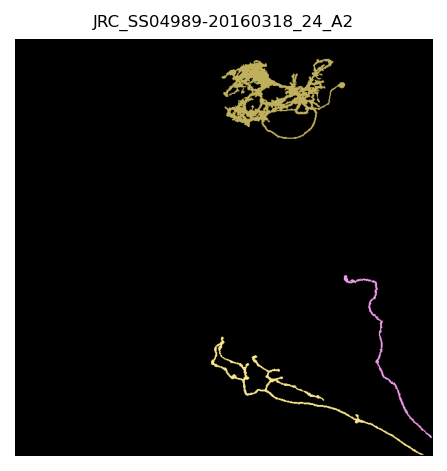

In [69]:
AUG_NAME = "biapy-no-aug"
no_aug_FS = (3, 3)
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED,
    sample_selection=1,
    subplots=(1, 1),
    fig_size=no_aug_FS
)
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    False, fisbe_gt_instance_mip, RNG_SEED,
    sample_selection=1,
    subplots=(1, 1),
    fig_size=no_aug_FS
)


### Channel-Rot

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-channel-rot/test/raw
JRC_SS04989-20160318_24_A2*
Total augmentations for sample found: 27
Selecting (4) samples


  0%|          | 0/4 [00:00<?, ?it/s]

Image Shape: (390, 3, 680, 680)
Image Shape: (680, 3, 390, 680)


 50%|█████     | 2/4 [00:05<00:04,  2.44s/it]

Image Shape: (390, 3, 680, 680)
Image Shape: (680, 3, 680, 390)


100%|██████████| 4/4 [00:10<00:00,  2.58s/it]


Transformed image shape: (390, 680, 3)


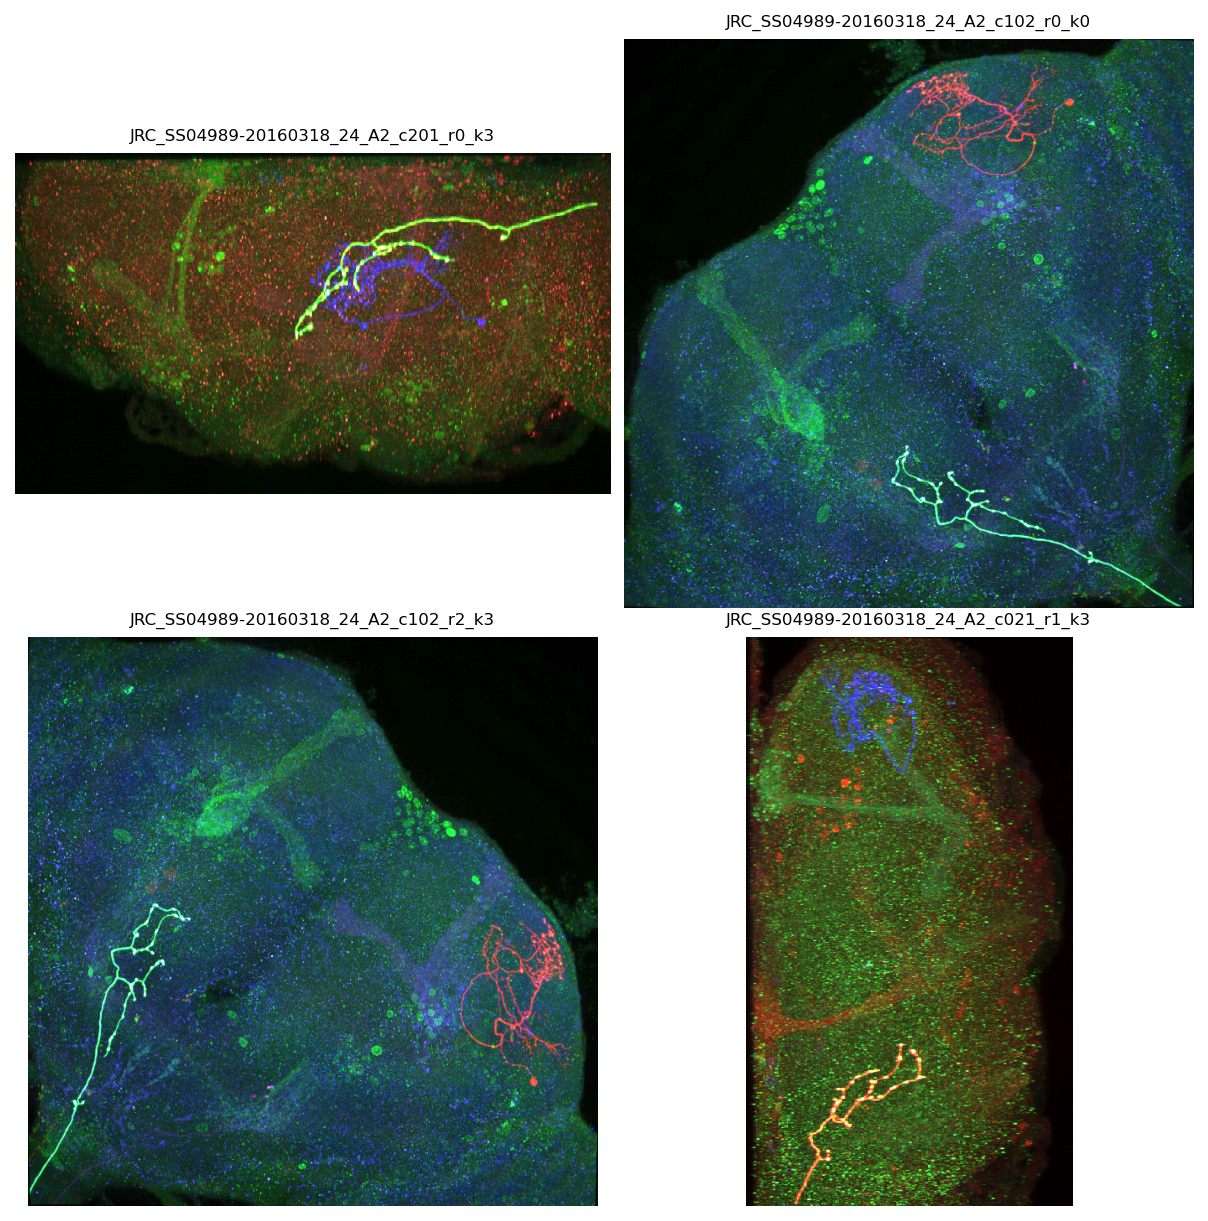

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-channel-rot/test/label
JRC_SS04989-20160318_24_A2*
Total augmentations for sample found: 27
Selecting (4) samples


 25%|██▌       | 1/4 [00:00<00:01,  1.81it/s]

Image Shape: (680, 390, 680)
Image Shape: (390, 680, 680)


100%|██████████| 4/4 [00:01<00:00,  3.50it/s]

Image Shape: (390, 680, 680)
Image Shape: (680, 680, 390)
Transformed image shape: (390, 680, 3)


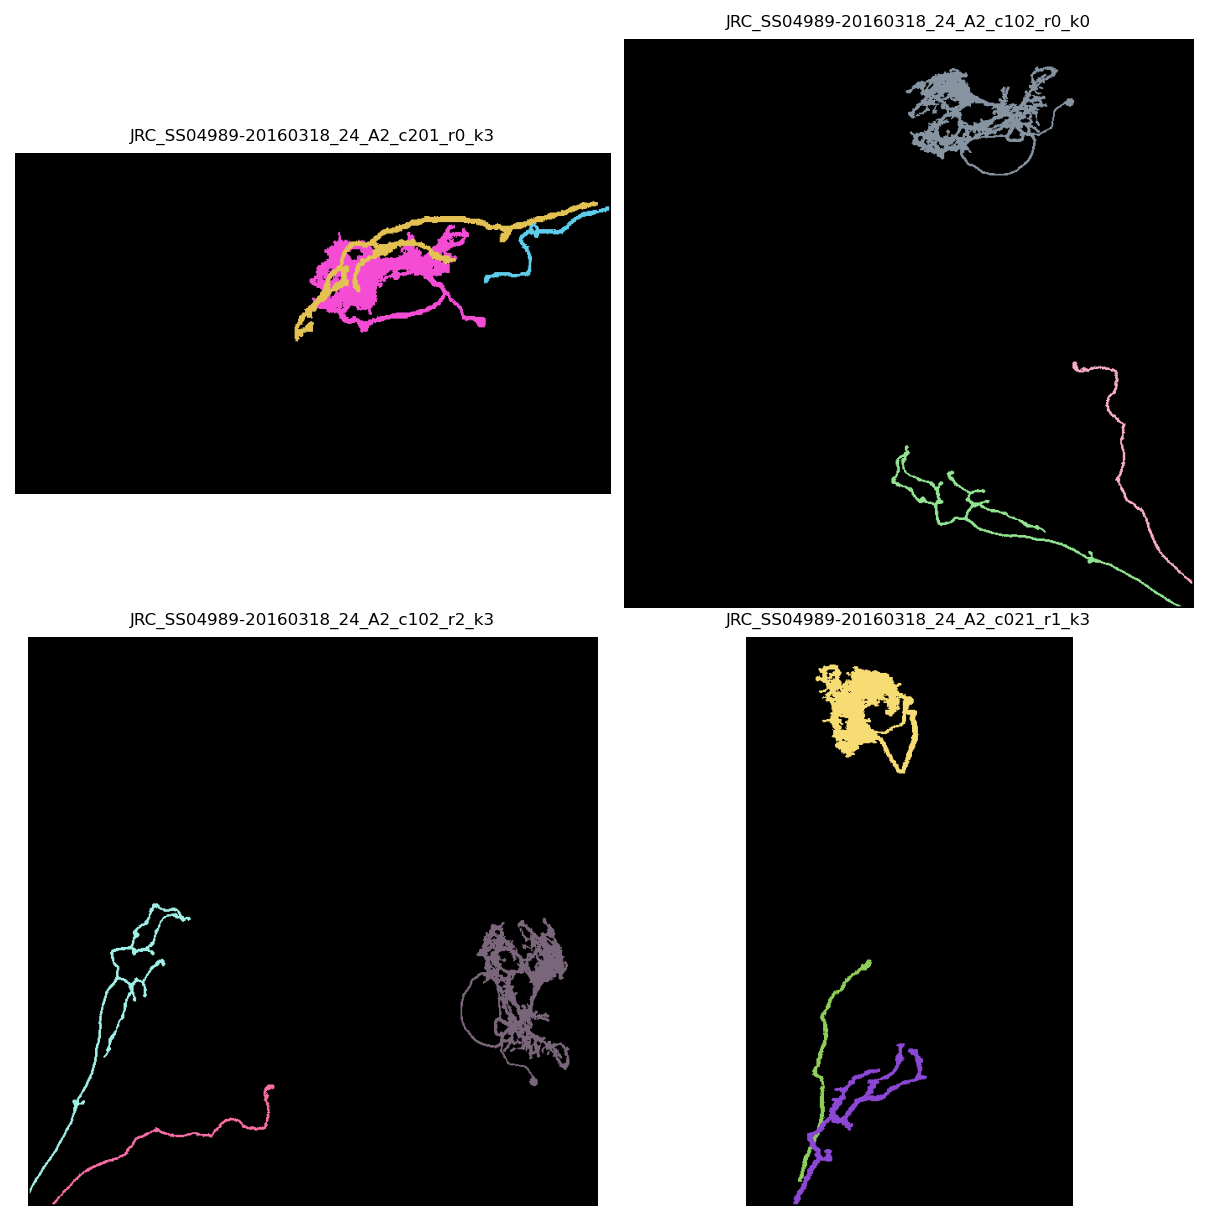

In [70]:
AUG_NAME = "biapy-channel-rot"
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED
)
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    False, fisbe_gt_instance_mip, RNG_SEED
)


### Channel Scale

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-channel-scale/test/raw
JRC_SS04989-20160318_24_A2*
Total augmentations for sample found: 1
Selecting (4) samples


  0%|          | 0/4 [00:00<?, ?it/s]

Image Shape: (390, 3, 680, 680)
Image Shape: (390, 3, 680, 680)


 25%|██▌       | 1/4 [00:05<00:17,  5.89s/it]

Image Shape: (390, 3, 680, 680)
Image Shape: (390, 3, 680, 680)


100%|██████████| 4/4 [00:12<00:00,  3.03s/it]


Transformed image shape: (680, 680, 3)


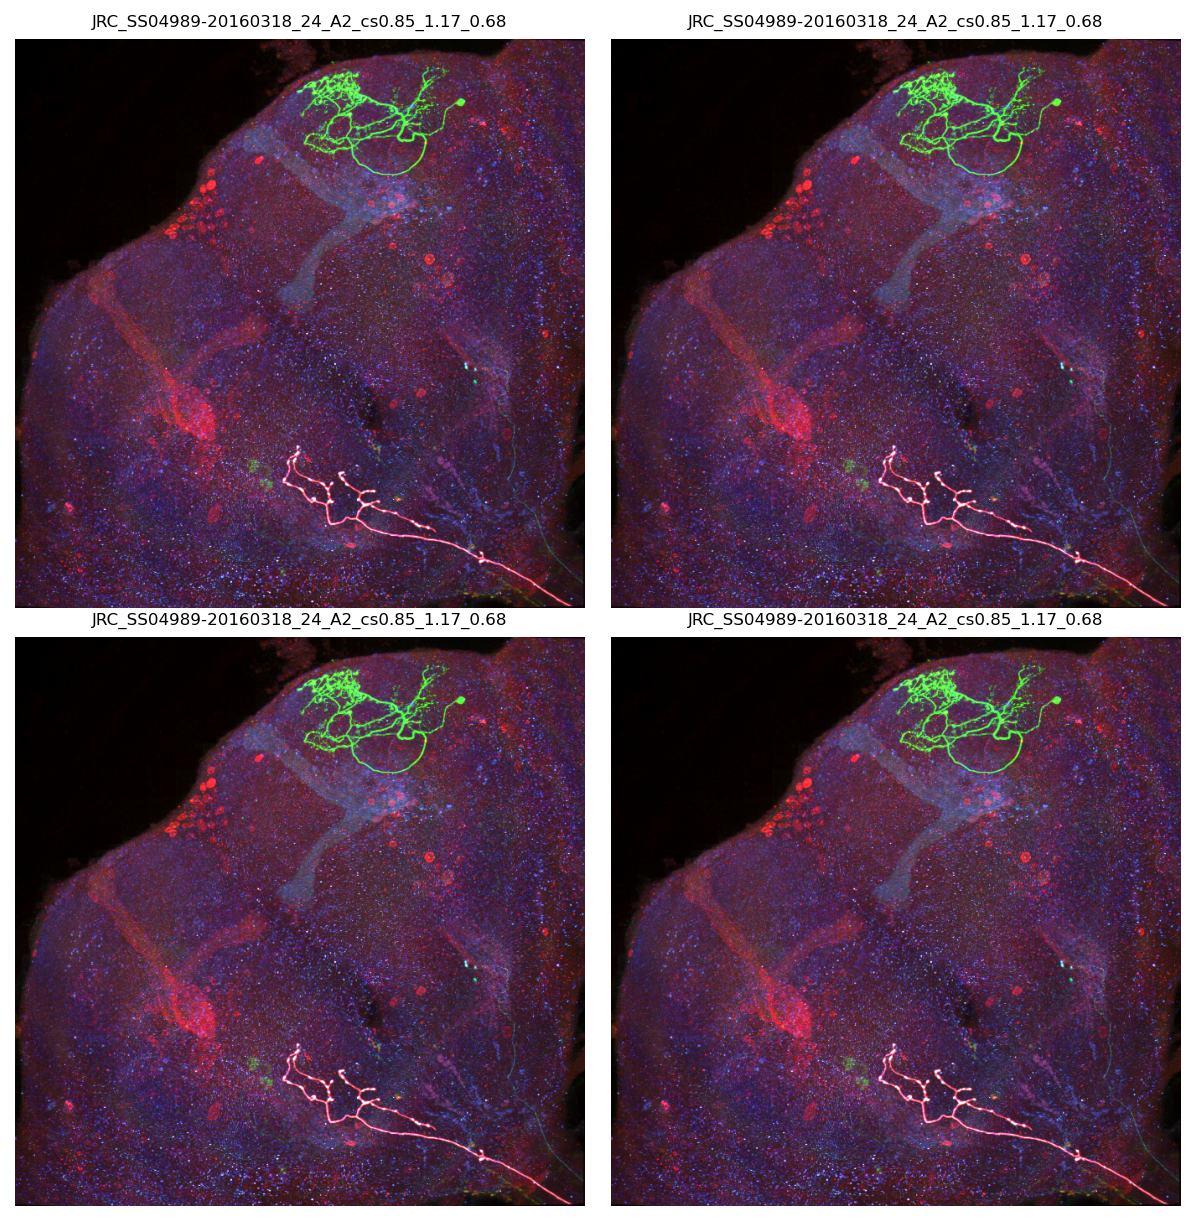

In [ ]:
AUG_NAME = "biapy-channel-scale"
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED,
)


### Instance Scale

/scratch/wmz2007/neuroinfo_fruitfly/fisbe/biapy-instance-scale/test/raw
JRC_SS04989-20160318_24_A2*
Total augmentations for sample found: 1
Selecting (4) samples


  0%|          | 0/4 [00:00<?, ?it/s]

Image Shape: (390, 3, 680, 680)
Image Shape: (390, 3, 680, 680)
Image Shape: (390, 3, 680, 680)


 75%|███████▌  | 3/4 [00:06<00:01,  1.77s/it]

Image Shape: (390, 3, 680, 680)


100%|██████████| 4/4 [00:08<00:00,  2.22s/it]


Transformed image shape: (680, 680, 3)


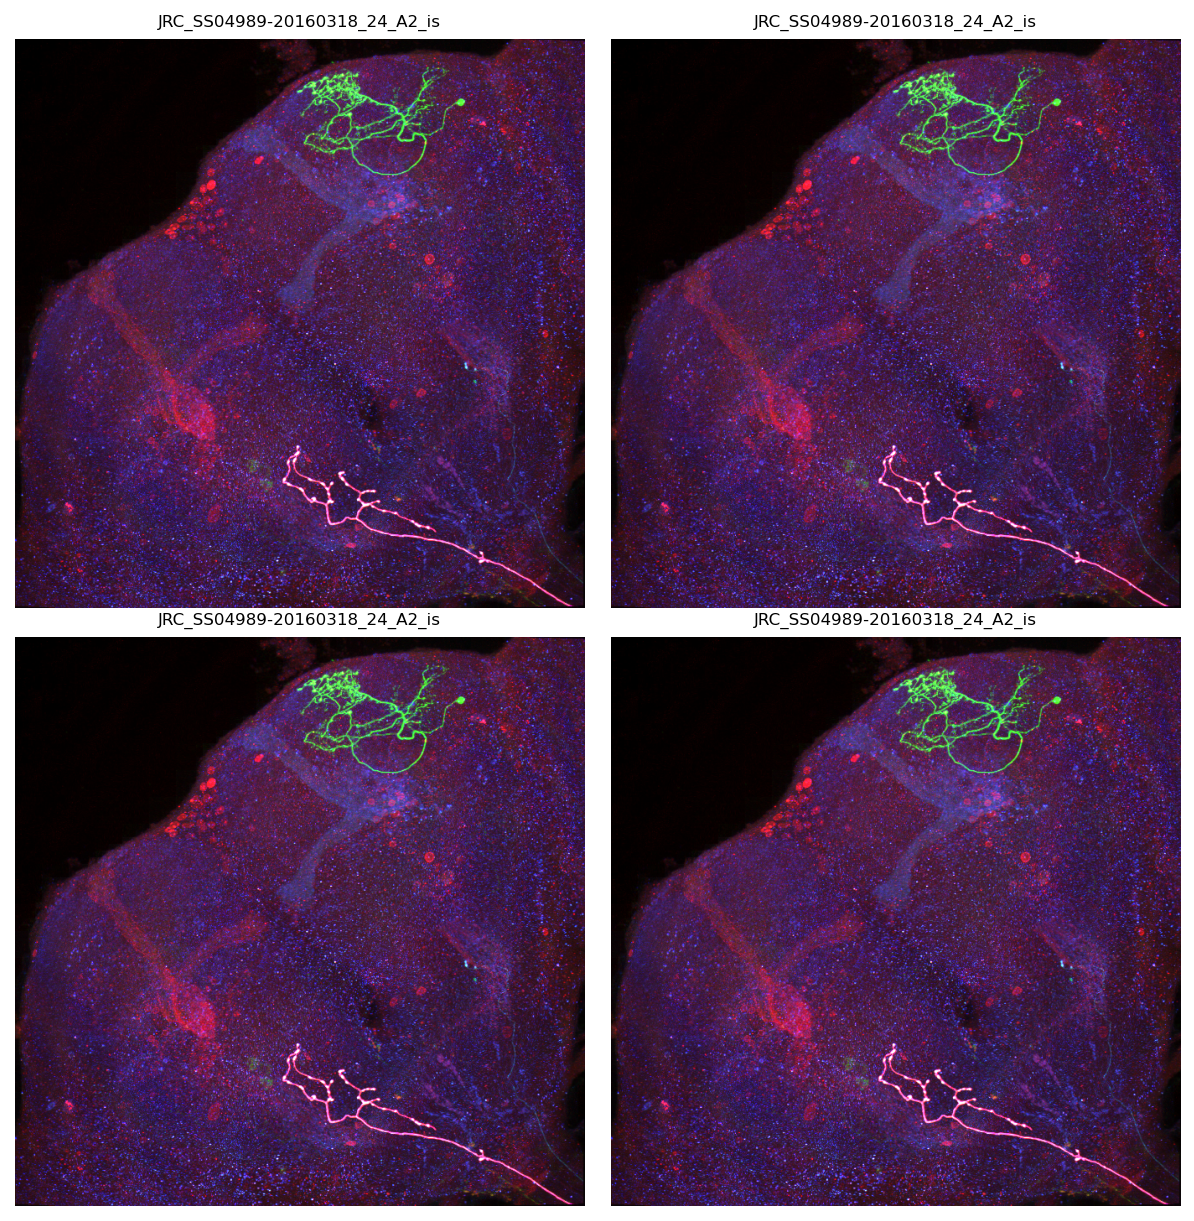

In [73]:
AUG_NAME = "biapy-instance-scale"
plot_augmentation_samples(
    SAMPLE, SPLIT, AUG_NAME,
    True, fisbe_rgb_mip, RNG_SEED
)
